# Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

# Task 1: Data Preparation

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.
Hints:

• Ensure that the images are resized to a consistent shape (e.g., 28x28).

• Convert labels to one-hot encoded format for multi-class classification.

In [1]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/sem6-AIandML/worksheet4/Train"
test_dir  = "/content/drive/MyDrive/sem6-AIandML/worksheet4/Test"
# Define image size
img_height, img_width = 28, 28

In [4]:
# Function to load images and labels using PIL
def load_images_from_folder(folder):
  images = []
  labels = []
  class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
  class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
  for class_name in class_names:
    class_path = os.path.join(folder, class_name)
    label = class_map[class_name]
    for filename in os.listdir(class_path):
      img_path = os.path.join(class_path, filename)
      # Load image using PIL
      img = Image.open(img_path).convert("L") # Convert to grayscale
      img = img.resize((img_width, img_height)) # Resize to (28,28)
      img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
      images.append(img)
      labels.append(label)
  return np.array(images), np.array(labels)

In [5]:
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")



Training set: (17006, 28, 28, 1), Labels: (17006, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


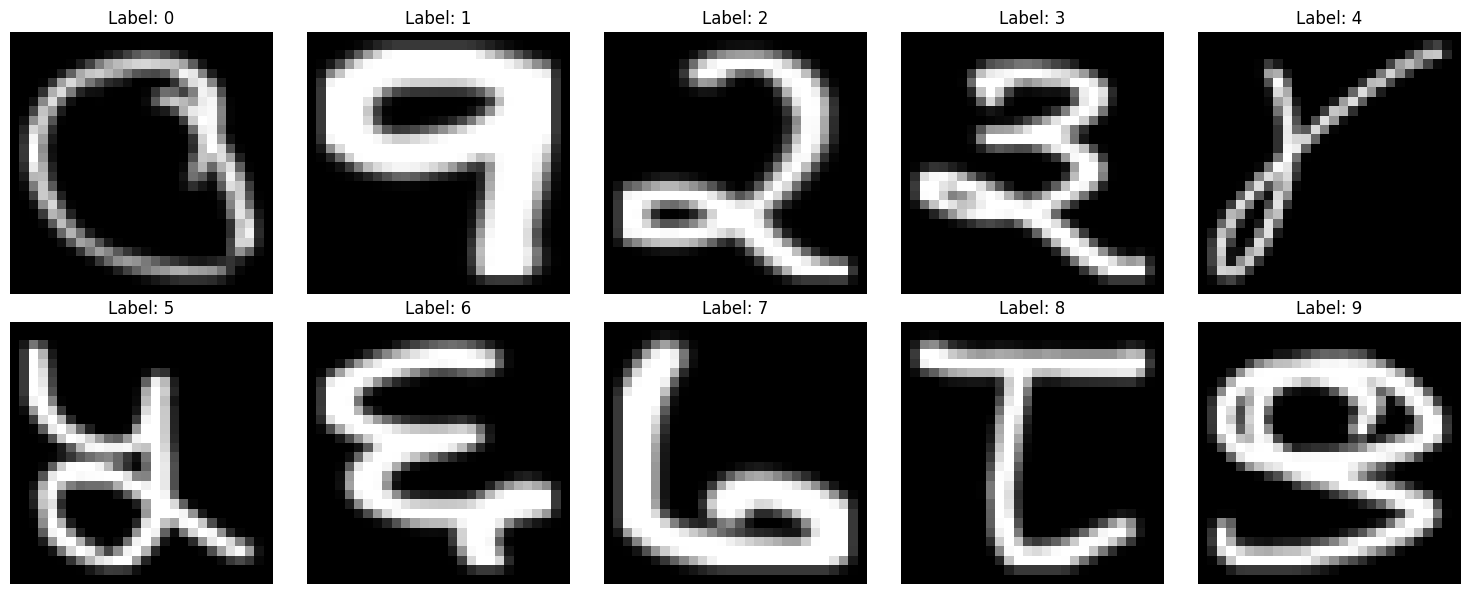

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Find the first index of each digit (0-9)
unique_indices = [np.where(np.argmax(y_train, axis=1) == i)[0][0] for i in range(10)]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(unique_indices):
    plt.subplot(2, 5, i + 1)

    # Reshape the flattened/channel data back to 28x28 for display
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')

    plt.title(f"Label: {i}", fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

---

# Task 2: Build the FCN Model

Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:
– 1st hidden layer: 64 neurons
– 2nd hidden layer: 128 neurons
– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [7]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

# Display the architecture summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the Model

Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [14]:
# Shuffle data to remove ordered label bias (0–9 sequence)
indices = np.arange(x_train.shape[0])
np.random.shuffle(indices)
x_train = x_train[indices]
y_train = y_train[indices]

In [15]:
batch_size = 128
epochs = 20

# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]

# Train the model with callbacks and validation split
history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.2,
  callbacks=callbacks,
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8718 - loss: 0.5029 - val_accuracy: 0.9389 - val_loss: 0.2615
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9462 - loss: 0.2050 - val_accuracy: 0.9550 - val_loss: 0.1740
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9610 - loss: 0.1462 - val_accuracy: 0.9583 - val_loss: 0.1469
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9694 - loss: 0.1129 - val_accuracy: 0.9627 - val_loss: 0.1267
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9762 - loss: 0.0920 - val_accuracy: 0.9685 - val_loss: 0.1163
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9792 - loss: 0.0780 - val_accuracy: 0.9671 - val_loss: 0.1083
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9838 - loss: 0.0638 - val_accuracy: 0.9724 - val_loss: 0.0982
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9873 - loss: 0.0533 - val_accuracy: 0.

# Task 5: Evaluate the Model

Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [16]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

94/94 - 0s - 4ms/step - accuracy: 0.9773 - loss: 0.0815

Test Accuracy: 0.9773
Test Loss: 0.0815


# Task 6: Save and Load the Model

Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [18]:
# Save the model
model.save("devnagari_model.h5")
print("Model saved to devnagari_model.h5")

# Load the model
loaded_model = tf.keras.models.load_model("devnagari_model.h5")



Model saved to devnagari_model.h5


In [19]:
# Re-evaluate performance
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Re-evaluated Accuracy: {acc:.4f}")

Re-evaluated Accuracy: 0.9773


# Task 7: Predictions

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model's predicted probabilities to digit labels using np.argmax().

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


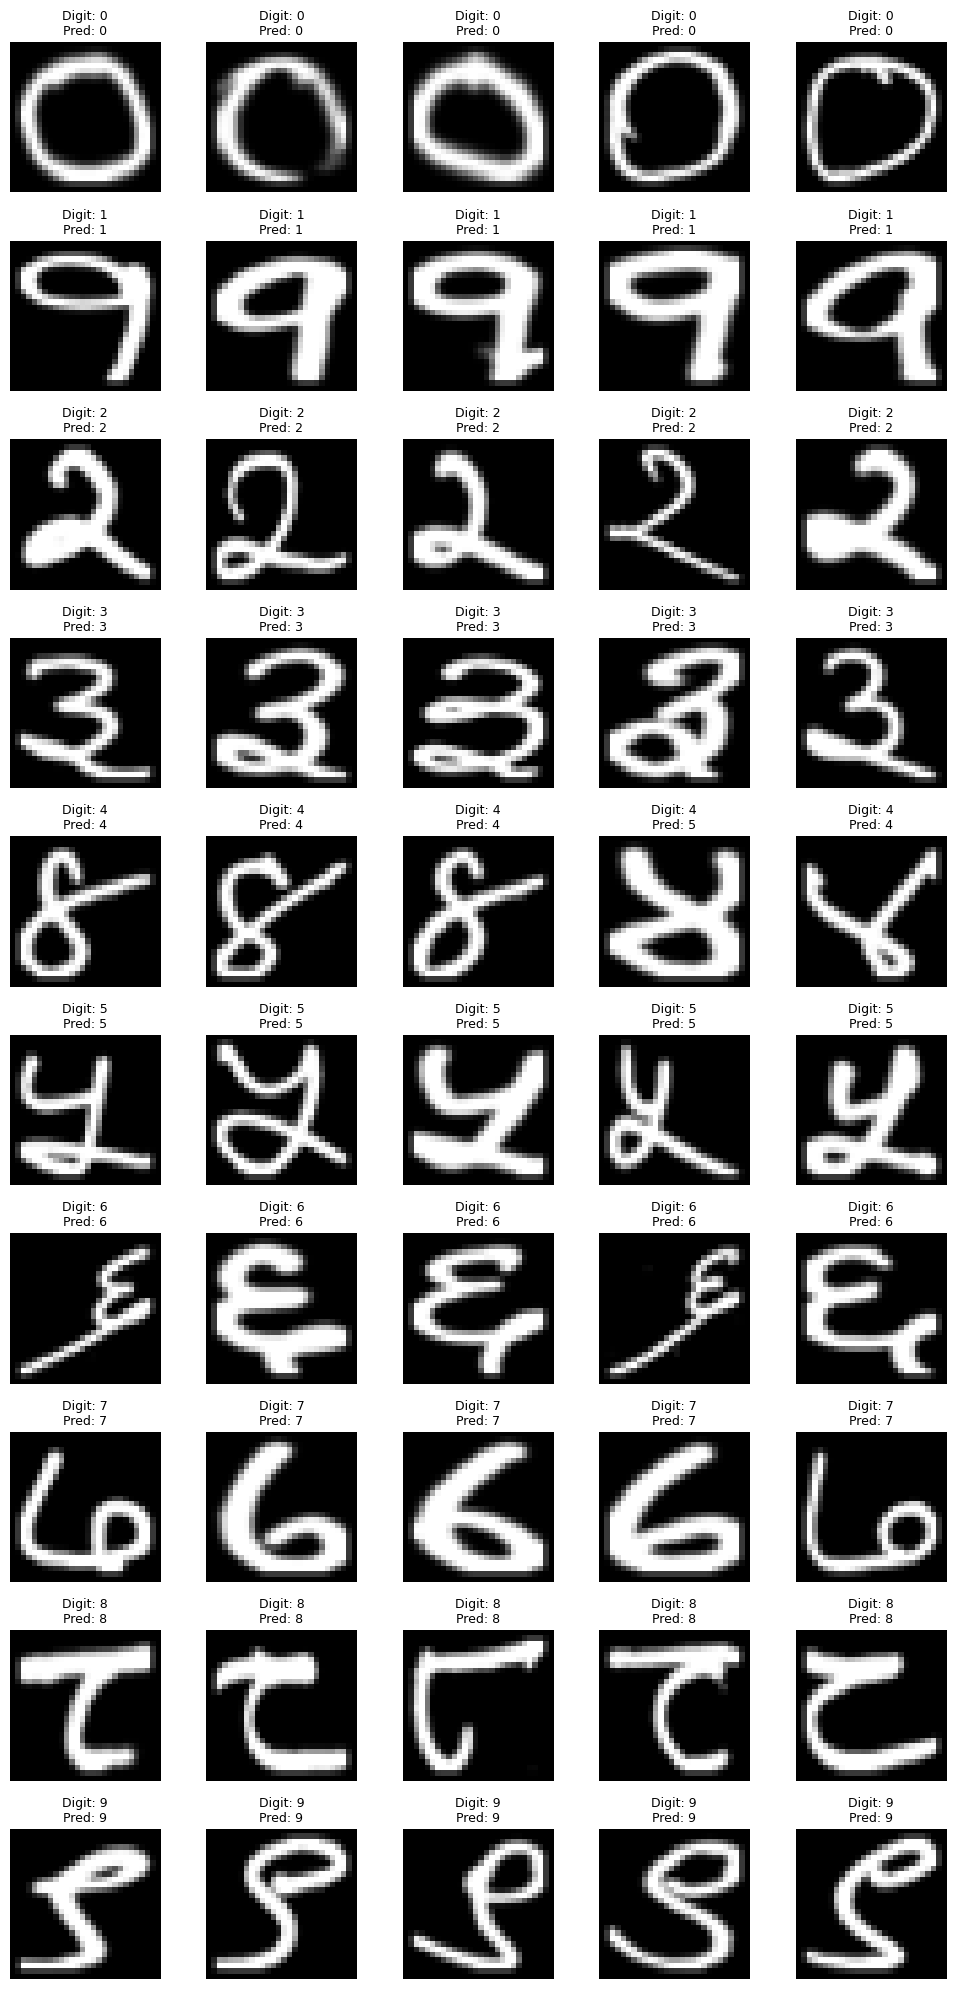

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Convert one-hot encoded y_test back to integer labels for easier filtering
y_test_integers = np.argmax(y_test, axis=1)
predictions_integers = np.argmax(loaded_model.predict(x_test), axis=1)

# Set up the plot: 10 rows (one for each digit), 5 columns (examples)
plt.figure(figsize=(10, 20))

for i in range(10):  # Loop through each digit 0-9
    # Find all indices where the true label is the current digit i
    indices = np.where(y_test_integers == i)[0]

    # Select the first 5 instances of this digit
    for j in range(5):
        if j < len(indices):
            idx = indices[j]

            # Create a subplot at the correct position in the 10x5 grid
            plt.subplot(10, 5, i * 5 + j + 1)

            # Show the image (reshaping if necessary)
            plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')

            # Add title showing prediction vs actual
            plt.title(f"Digit: {i}\nPred: {predictions_integers[idx]}", fontsize=9)
            plt.axis("off")

plt.tight_layout()
plt.show()